# CH 5 - 5 : TEST CONCLUSIONS AND ERRORS

## Objectif pédagogique

Ce notebook explique les **conclusions possibles d'un test d'hypothèse** et les **deux grandes erreurs statistiques** qui peuvent apparaître lorsqu'on valide une règle de trading.

Dans le cadre EBTA, le but n'est pas de croire naïvement un backtest profitable.  
Le but est de décider si le profit observé est suffisamment improbable sous l'hypothèse suivante :

> $H_0$ : la règle n'a aucun talent prédictif réel.

Le trader ne peut jamais connaître directement la vérité absolue. Il prend donc une décision sous incertitude, avec deux risques majeurs :

- **Erreur de Type I** : croire à une stratégie nulle.
- **Erreur de Type II** : rejeter ou ignorer une stratégie réellement valide.

La logique EBTA privilégie la protection du capital : il vaut mieux rater une opportunité que risquer son capital sur une illusion statistique.


## 1. Les quatre issues possibles d'un test

Un test statistique compare deux choses :

1. **La réalité**, qui est inconnue au moment du test.
2. **La décision du trader**, basée sur les données disponibles.

Cela donne quatre issues possibles :

| Réalité | Décision du test | Résultat |
|---|---|---|
| La règle est vraiment nulle | On retient $H_0$ | Décision correcte |
| La règle est vraiment nulle | On rejette $H_0$ | Erreur de Type I |
| La règle a vraiment un edge | On rejette $H_0$ | Décision correcte |
| La règle a vraiment un edge | On retient $H_0$ | Erreur de Type II |

En trading, la distinction est capitale :

- **Type I** = prendre de la chance pour du talent.
- **Type II** = prendre du talent pour de la chance.

Le Type I est généralement plus dangereux, car il peut mener à trader une règle sans espérance positive réelle.


## 2. Analogie trading simple

Imagine que tu testes une règle ICT / price action sur un historique.

Tu obtiens un profit positif.

Deux explications sont possibles :

### Explication A : la règle a vraiment un edge

Le setup exploite une inefficience réelle du marché.  
Le profit du backtest reflète une capacité prédictive exploitable.

### Explication B : la règle a eu de la chance

La règle n'a aucun talent réel.  
Mais, sur cet échantillon précis, elle est tombée par hasard sur des conditions favorables.

Le test d'hypothèse sert à répondre à cette question :

> Est-ce que le profit observé est trop rare pour être raisonnablement expliqué par la chance ?

Mais même avec un test rigoureux, il reste un risque d'erreur.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres généraux
n_trades = 100
n_simulations = 20_000

# Hypothèse nulle : la règle n'a aucun edge
mu_null = 0.0

# Hypothèse alternative : la règle a un petit edge réel
mu_edge = 0.10

# Volatilité des rendements par trade
sigma = 1.0

# Seuil de décision
alpha = 0.05

print("Paramètres de simulation")
print("------------------------")
print(f"Nombre de trades par backtest : {n_trades}")
print(f"Nombre de backtests simulés : {n_simulations}")
print(f"Rendement moyen sous H0 : {mu_null}")
print(f"Rendement moyen si edge réel : {mu_edge}")
print(f"Volatilité par trade : {sigma}")
print(f"Seuil alpha : {alpha}")

Paramètres de simulation
------------------------
Nombre de trades par backtest : 100
Nombre de backtests simulés : 20000
Rendement moyen sous H0 : 0.0
Rendement moyen si edge réel : 0.1
Volatilité par trade : 1.0
Seuil alpha : 0.05


## 3. Simuler des backtests sous $H_0$

Ici, on simule des milliers de backtests d'une règle qui **n'a aucun edge réel**.

Cela représente le monde où $H_0$ est vraie.

Même si la moyenne vraie est zéro, certains backtests seront positifs par hasard.

C'est exactement le terrain de l'**erreur de Type I**.


In [2]:
# Simulation sous H0 : stratégie sans edge
returns_null = np.random.normal(mu_null, sigma, size=(n_simulations, n_trades))
means_null = returns_null.mean(axis=1)

# Erreur standard de la moyenne
standard_error = sigma / np.sqrt(n_trades)

# Seuil critique one-sided à alpha = 5%
# Pour un test unilatéral, on rejette H0 si la moyenne observée dépasse ce seuil.
critical_value = 1.645 * standard_error

type_1_errors = means_null > critical_value
type_1_error_rate = type_1_errors.mean()

print(f"Seuil critique de moyenne : {critical_value:.4f}")
print(f"Taux empirique d'erreur Type I : {type_1_error_rate:.4%}")

Seuil critique de moyenne : 0.1645
Taux empirique d'erreur Type I : 5.0600%


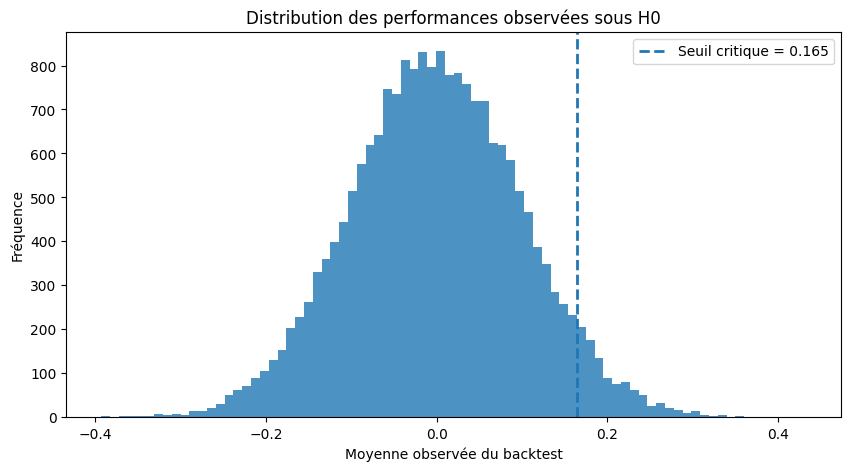

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(means_null, bins=80, alpha=0.8)
plt.axvline(critical_value, linestyle="--", linewidth=2, label=f"Seuil critique = {critical_value:.3f}")
plt.title("Distribution des performances observées sous H0")
plt.xlabel("Moyenne observée du backtest")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

### Lecture du graphique

La majorité des backtests sans edge réel donnent une moyenne proche de zéro.

Mais la queue droite contient des backtests faussement prometteurs.

Ces cas correspondent à :

> une règle nulle qui semble statistiquement bonne.

C'est l'erreur de **Type I**.

En trading, elle revient à mettre du capital derrière une stratégie qui a seulement été chanceuse en backtest.


## 4. Simuler des backtests avec un vrai edge

Maintenant, on simule une règle qui possède réellement un petit edge.

Cela représente le monde où $H_0$ est fausse.

Mais même avec un edge réel, certains backtests peuvent être décevants à cause du bruit, de la volatilité ou d'un échantillon trop petit.

C'est le terrain de l'**erreur de Type II**.


In [4]:
# Simulation sous HA : stratégie avec edge réel
returns_edge = np.random.normal(mu_edge, sigma, size=(n_simulations, n_trades))
means_edge = returns_edge.mean(axis=1)

# Décision du test
reject_h0_when_edge_exists = means_edge > critical_value

power = reject_h0_when_edge_exists.mean()
type_2_error_rate = 1 - power

print(f"Puissance statistique du test : {power:.4%}")
print(f"Taux empirique d'erreur Type II : {type_2_error_rate:.4%}")

Puissance statistique du test : 25.8550%
Taux empirique d'erreur Type II : 74.1450%


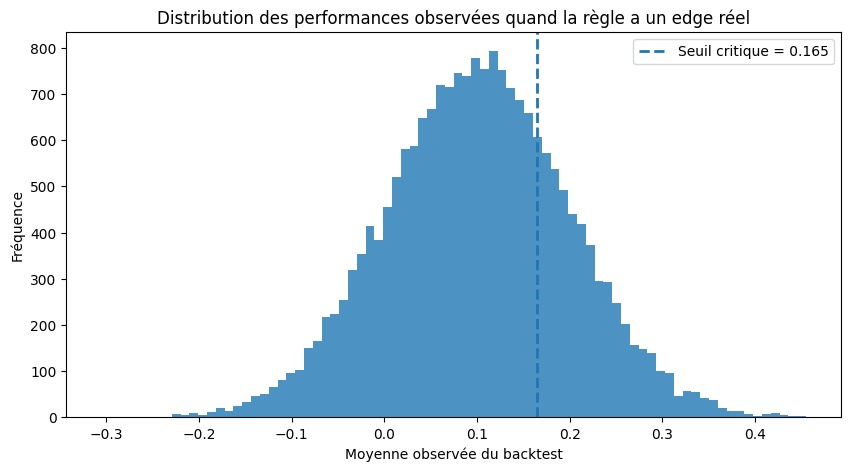

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(means_edge, bins=80, alpha=0.8)
plt.axvline(critical_value, linestyle="--", linewidth=2, label=f"Seuil critique = {critical_value:.3f}")
plt.title("Distribution des performances observées quand la règle a un edge réel")
plt.xlabel("Moyenne observée du backtest")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

### Lecture du graphique

Même quand la stratégie a un edge réel, tous les backtests ne dépassent pas le seuil critique.

Les cas à gauche du seuil représentent :

> une règle réellement prédictive qui n'est pas reconnue comme telle par le test.

C'est l'erreur de **Type II**.

Elle fait manquer une opportunité, mais ne détruit pas directement le capital.


## 5. Comparer les deux mondes : règle nulle vs règle avec edge

Le test trace une frontière entre :

- ce qu'on accepte comme bruit normal,
- ce qu'on considère comme suffisamment improbable pour rejeter $H_0$.

Cette frontière est le **seuil critique**.

Plus le seuil est strict, plus on réduit les faux positifs, mais plus on risque aussi de rater de vrais edges.


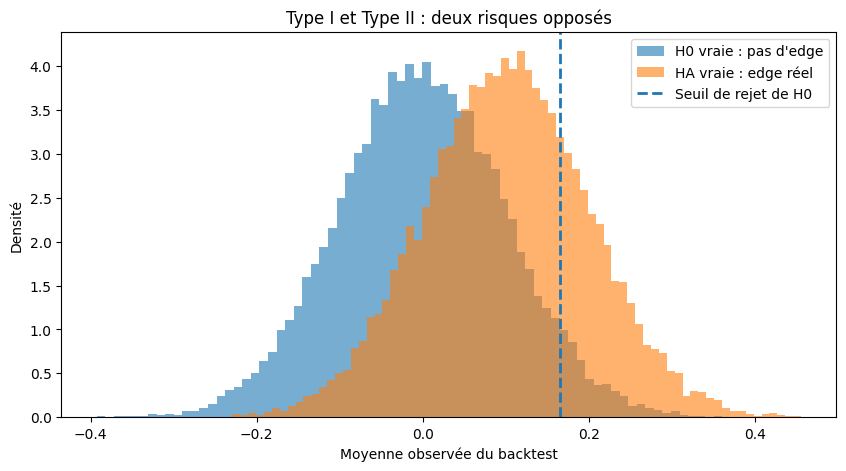

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(means_null, bins=80, alpha=0.6, density=True, label="H0 vraie : pas d'edge")
plt.hist(means_edge, bins=80, alpha=0.6, density=True, label="HA vraie : edge réel")
plt.axvline(critical_value, linestyle="--", linewidth=2, label="Seuil de rejet de H0")
plt.title("Type I et Type II : deux risques opposés")
plt.xlabel("Moyenne observée du backtest")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 6. Tableau de décision EBTA

Construisons maintenant une matrice simple.

Dans cette matrice :

- la **réalité** est soit : règle nulle ou règle avec edge ;
- la **décision** est soit : retenir $H_0$ ou rejeter $H_0$.

Le danger majeur pour le trader est le faux positif.


In [7]:
decision_matrix = pd.DataFrame(
    {
        "Retenir H0": [
            "Décision correcte : on évite une règle nulle",
            "Erreur Type II : on rate une bonne règle"
        ],
        "Rejeter H0": [
            "Erreur Type I : on trade une illusion",
            "Décision correcte : on valide une règle utile"
        ],
    },
    index=[
        "Réalité : règle nulle",
        "Réalité : règle avec edge"
    ]
)

decision_matrix

,Retenir H0,Rejeter H0
Réalité : règle nulle,Décision correcte : on évite une règle nulle,Erreur Type I : on trade une illusion
Réalité : règle avec edge,Erreur Type II : on rate une bonne règle,Décision correcte : on valide une règle utile


## 7. Pourquoi le Type I est plus grave pour le trader

L'erreur de Type I est asymétriquement dangereuse.

Elle signifie :

> je crois avoir trouvé un edge, mais je n'ai trouvé que du bruit.

Conséquences possibles :

- allocation de capital sur une règle sans espérance ;
- pertes réelles en live ;
- confiance excessive dans une illusion ;
- augmentation du risque psychologique ;
- destruction progressive du capital.

L'erreur de Type II est frustrante, mais moins fatale :

> je rate une bonne stratégie.

Cela coûte une opportunité, mais cela ne force pas directement une perte de capital.

C'est pourquoi l'EBTA adopte une posture conservatrice.


## 8. Effet de la taille d'échantillon sur la puissance

Une stratégie peut avoir un vrai edge et pourtant échouer au test si l'échantillon est trop petit.

La raison est simple :

> plus l'échantillon est petit, plus la distribution d'échantillonnage est large.

Avec plus de trades, l'estimation moyenne devient plus stable.  
Le test détecte plus facilement un vrai edge.

On va maintenant simuler la puissance du test selon le nombre de trades.


In [8]:
sample_sizes = [25, 50, 100, 250, 500, 1000]
results = []

for n in sample_sizes:
    se = sigma / np.sqrt(n)
    cv = 1.645 * se

    null_samples = np.random.normal(mu_null, sigma, size=(n_simulations, n))
    edge_samples = np.random.normal(mu_edge, sigma, size=(n_simulations, n))

    null_means = null_samples.mean(axis=1)
    edge_means = edge_samples.mean(axis=1)

    type_1 = (null_means > cv).mean()
    power_n = (edge_means > cv).mean()
    type_2 = 1 - power_n

    results.append({
        "Nombre de trades": n,
        "Seuil critique": cv,
        "Erreur Type I": type_1,
        "Puissance": power_n,
        "Erreur Type II": type_2
    })

power_df = pd.DataFrame(results)
power_df

,Nombre de trades,Seuil critique,Erreur Type I,Puissance,Erreur Type II
0,25,0.329000,0.05015,0.12750,0.87250
1,50,0.232638,0.04845,0.17710,0.82290
2,100,0.164500,0.04900,0.25325,0.74675
3,250,0.104039,0.05105,0.47620,0.52380
4,500,0.073567,0.05005,0.71805,0.28195
5,1000,0.052019,0.04960,0.93640,0.06360


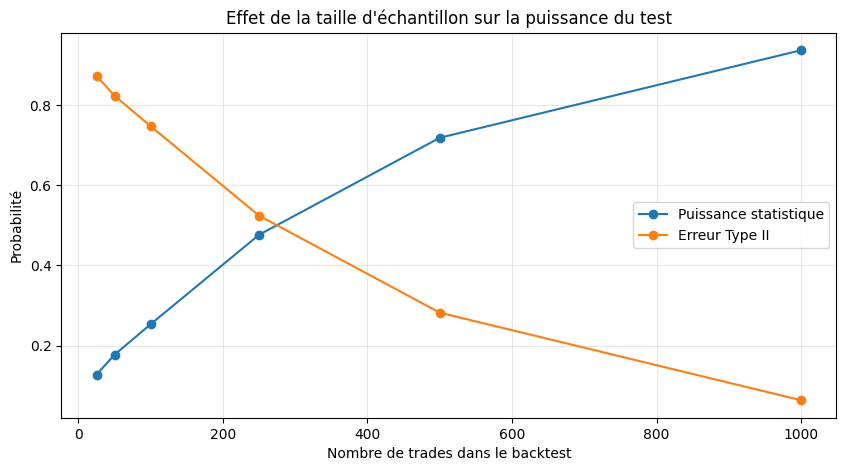

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(power_df["Nombre de trades"], power_df["Puissance"], marker="o", label="Puissance statistique")
plt.plot(power_df["Nombre de trades"], power_df["Erreur Type II"], marker="o", label="Erreur Type II")
plt.title("Effet de la taille d'échantillon sur la puissance du test")
plt.xlabel("Nombre de trades dans le backtest")
plt.ylabel("Probabilité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Lecture pratique

Quand le nombre de trades augmente :

- la puissance statistique augmente ;
- l'erreur de Type II diminue ;
- le test devient meilleur pour détecter un vrai edge.

Mais attention : augmenter l'historique ne doit pas se faire au prix d'une mauvaise qualité de données, d'un changement de régime ignoré ou d'une règle qui n'a plus de sens économiquement.


## 9. Influence du seuil alpha

Le seuil alpha contrôle le risque de Type I.

Un alpha de 5 % signifie :

> si la règle est vraiment nulle, on accepte environ 5 % de risque de la valider à tort.

Mais si on rend le seuil plus strict, par exemple 1 %, on réduit les faux positifs tout en augmentant le risque de rater de vrais edges.

C'est le compromis central.


In [10]:
alphas = [0.10, 0.05, 0.01]
z_values = {
    0.10: 1.282,
    0.05: 1.645,
    0.01: 2.326
}

alpha_results = []

for a in alphas:
    z = z_values[a]
    cv = z * standard_error

    type_1 = (means_null > cv).mean()
    power_a = (means_edge > cv).mean()
    type_2 = 1 - power_a

    alpha_results.append({
        "Alpha": a,
        "Seuil critique": cv,
        "Erreur Type I": type_1,
        "Puissance": power_a,
        "Erreur Type II": type_2
    })

alpha_df = pd.DataFrame(alpha_results)
alpha_df

,Alpha,Seuil critique,Erreur Type I,Puissance,Erreur Type II
0,0.10,0.1282,0.09815,0.38955,0.61045
1,0.05,0.1645,0.05060,0.25855,0.74145
2,0.01,0.2326,0.01055,0.09095,0.90905


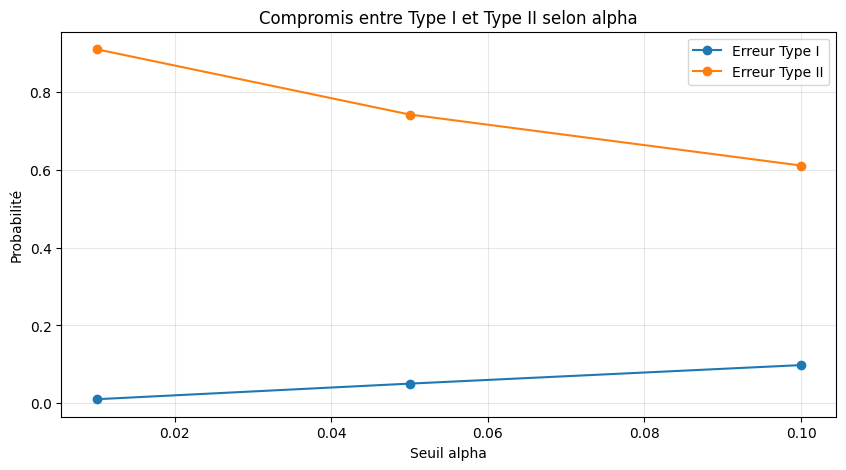

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(alpha_df["Alpha"], alpha_df["Erreur Type I"], marker="o", label="Erreur Type I")
plt.plot(alpha_df["Alpha"], alpha_df["Erreur Type II"], marker="o", label="Erreur Type II")
plt.title("Compromis entre Type I et Type II selon alpha")
plt.xlabel("Seuil alpha")
plt.ylabel("Probabilité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Application directe à ton process de trader

Dans ton contexte EBTA / trading mécanique, la leçon est claire.

### Quand une règle passe le test

Tu ne dis pas :

> cette règle est vraie à 100 %.

Tu dis plutôt :

> les preuves disponibles sont assez fortes pour rejeter l'idée qu'elle est nulle, avec un risque contrôlé de faux positif.

### Quand une règle échoue au test

Tu ne dis pas forcément :

> cette règle est nulle.

Tu dis plutôt :

> je n'ai pas assez de preuves pour engager du capital réel.

C'est une différence mentale énorme.

Le test ne donne pas une certitude.  
Il donne une discipline de décision.


## 11. Règle mentale EBTA

Voici une formulation simple :

> Mon rôle n'est pas de sauver une stratégie ambiguë.  
> Mon rôle est de protéger mon capital contre les illusions statistiques.

Donc :

- si la preuve est forte, je peux avancer ;
- si la preuve est faible, je ne force pas ;
- si le résultat est ambigu, je protège mon capital ;
- si je rate une opportunité, ce n'est pas fatal ;
- si je finance une illusion, je peux sortir du jeu.

C'est la raison pour laquelle Aronson considère l'erreur de Type I comme plus grave.


## 12. Résumé final

### Type I

Erreur de faux positif.

> Je rejette $H_0$ alors que $H_0$ est vraie.

En trading :

> je crois avoir trouvé un edge, mais je trade une règle nulle.

Danger principal :

> perte de capital sur une illusion.

### Type II

Erreur de faux négatif.

> Je retiens $H_0$ alors que $H_0$ est fausse.

En trading :

> je jette ou ignore une règle qui avait réellement du potentiel.

Danger principal :

> opportunité manquée.

### Principe EBTA

> Mieux vaut manquer un gain que financer une illusion.

Le test statistique n'est donc pas une machine à certitude.  
C'est un système de gestion du risque d'erreur.
